### YOLOv8 Image Detection (Notebook Version)
This notebook cell performs object detection using a pretrained YOLOv8 Large (yolov8l.pt) model.
What this code does:
- Loads a pretrained YOLO model.
- Checks whether the image file exists.
- Runs inference on the image.
- Draws bounding boxes and labels on detected objects.
- Displays the annotated result inline in the notebook.


image 1/1 /home/administrator/repos/yolo-testing/images/test.jpg: 640x480 4 persons, 1 bus, 424.8ms
Speed: 1.5ms preprocess, 424.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /home/administrator/repos/yolo-testing/images/snapshot.jpg: 384x640 6 cars, 2 potted plants, 354.5ms
Speed: 1.3ms preprocess, 354.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/administrator/repos/yolo-testing/images/parkeerplaats.jpg: 384x640 10 cars, 2 trucks, 324.5ms
Speed: 1.1ms preprocess, 324.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


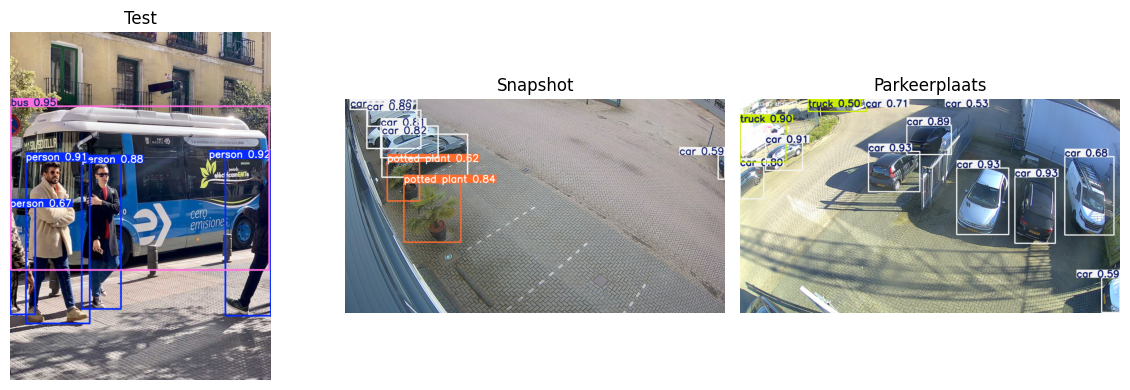

In [25]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

model = YOLO("yolov8l.pt")

def detect(image_path: str, conf: float = 0.5):
    #load the image and check if it exists
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path.resolve()}")
    
    #perform detection
    results = model(str(image_path), conf=conf)

    #annotate the image with the results
    r = results[0]
    annotated = r.plot()
    return annotated

#detect the image and get the annotated result
img1 = detect("images/test.jpg")
img2 = detect("images/snapshot.jpg")
img3 = detect("images/parkeerplaats.jpg")

#display the annotated images using matplotlib
images = [img1, img2, img3]
titles = ["Test", "Snapshot", "Parkeerplaats"]

plt.figure(figsize=(12, 4))

for i, img in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()